In [1]:
#bibliotecas
import cv2 #procesamiento de imagenes
import matplotlib as mpl
import numpy as np
import pandas as pd
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import zipfile
from typing import Tuple
#entorno

import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

2025-10-31 08:05:26.290661: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1


In [2]:
from matplotlib import pyplot as plt
#%matplotlib inline #visualizar imagenes en el notebook

!ls -lh /home/marc/MARIADELMAR_EXPERIMENTS/HAM10000_images_part_*.zip

import zipfile
import os

zip_files = [
    "/home/marc/MARIADELMAR_EXPERIMENTS/HAM10000_images_part_1.zip",
    "/home/marc/MARIADELMAR_EXPERIMENTS/HAM10000_images_part_2.zip"
]

output_folder = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"
os.makedirs(output_folder, exist_ok=True)

for zip_path in zip_files:
    print(f"Extrayendo {os.path.basename(zip_path)} ...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(output_folder)
        print(f"{os.path.basename(zip_path)} extraído correctamente ✅")
    except zipfile.BadZipFile:
        print(f"⚠️ Error: {os.path.basename(zip_path)} está corrupto o incompleto.")



-rw-rw-r-- 1 marc marc 1,3G oct 16 20:22 /home/marc/MARIADELMAR_EXPERIMENTS/HAM10000_images_part_1.zip
-rw-rw-r-- 1 marc marc 1,4G oct 16 20:01 /home/marc/MARIADELMAR_EXPERIMENTS/HAM10000_images_part_2.zip
Extrayendo HAM10000_images_part_1.zip ...
HAM10000_images_part_1.zip extraído correctamente ✅
Extrayendo HAM10000_images_part_2.zip ...
HAM10000_images_part_2.zip extraído correctamente ✅


In [3]:
HAM10000_DATASET_PATH = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files"
HAM10000_IMAGES_PATH = os.path.join(HAM10000_DATASET_PATH, "images")
METADATA_PATH = os.path.join(HAM10000_DATASET_PATH, "HAM10000_metadata")



#archivos csv con one-hot encoding
PROJECT_PATH = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files"

HAM10000_TRAIN_CSV = os.path.join(PROJECT_PATH, "train_onehot.csv")
HAM10000_VAL_CSV   = os.path.join(PROJECT_PATH, "val_onehot.csv")  
HAM10000_TEST_CSV  = os.path.join(PROJECT_PATH, "test_onehot.csv")

#Leer csv (paso a dataframe)
HAM10000_TRAIN_DF = pd.read_csv(HAM10000_TRAIN_CSV)
HAM10000_VAL_DF   = pd.read_csv(HAM10000_VAL_CSV)
HAM10000_TEST_DF  = pd.read_csv(HAM10000_TEST_CSV)

#como ya tengo mis csv de train/val/test en one-hot encoding, separo la label de la imagen (image_id) y su vector one-hot de cada conjunto para crear las listas:
HAM10000_TRAIN_IMAGES = HAM10000_TRAIN_DF["image_id"].tolist()
HAM10000_TRAIN_LABELS = HAM10000_TRAIN_DF.drop(columns=["image_id"]).values

HAM10000_VAL_IMAGES = HAM10000_VAL_DF["image_id"].tolist()
HAM10000_VAL_LABELS = HAM10000_VAL_DF.drop(columns=["image_id"]).values

HAM10000_TEST_IMAGES = HAM10000_TEST_DF["image_id"].tolist()
HAM10000_TEST_LABELS = HAM10000_TEST_DF.drop(columns=["image_id"]).values

#Creo diccionarios con los 3 conjuntos image_id: vetor one-hot.
HAM10000_LABELS_DICT = {}
HAM10000_LABELS_DICT.update(dict(zip(HAM10000_TRAIN_IMAGES, HAM10000_TRAIN_LABELS)))
HAM10000_LABELS_DICT.update(dict(zip(HAM10000_VAL_IMAGES, HAM10000_VAL_LABELS)))
HAM10000_LABELS_DICT.update(dict(zip(HAM10000_TEST_IMAGES, HAM10000_TEST_LABELS)))


In [4]:
#Implementació del generador:
#1. primero normalizamos los valores de píxeles de una imagen a [-1, 1] 
#2. Aplicar generador de tensorflow que me devuelva la imagen y el vector en formato numpy en one-hot.

In [5]:
def normalize_image(image):
    return image / 255.0
    #return image / 255.0 si quiero normalizar a [0,1]
#tupla (alto,ancho,canales)

def dataset_generator(image_name: tf.Tensor, files_path: str = HAM10000_IMAGES_PATH, output_size: Tuple=(256, 256, 3)) -> Tuple[tf.Tensor, tf.Tensor]:
    image_name_str = image_name.numpy().decode() #convertir a str
    
    image_path = os.path.join(files_path, image_name_str + ".jpg") #ruta (imagenes jpg)

    image = cv2.imread(image_path)  # Primero guardar sin procesar
    if image is None:
        raise ValueError(f"No se pudo cargar la imagen: {image_path}")
    
    image = image[:, :, ::-1] #caneles RGB para keras
    image = cv2.resize(image, (output_size[1], output_size[0])) #ajustar el tamaño de la imagen

    image = normalize_image(image) #normalizar (pasar de [0,255] a [0,1])

    label = HAM10000_LABELS_DICT[image_name_str]
    
    return image, label

2025-10-31 08:05:53.424773: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcuda.so.1
2025-10-31 08:05:53.439221: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 0 with properties: 
pciBusID: 0000:06:00.0 name: GeForce GTX 1080 Ti computeCapability: 6.1
coreClock: 1.582GHz coreCount: 28 deviceMemorySize: 10.92GiB deviceMemoryBandwidth: 451.17GiB/s
2025-10-31 08:05:53.439306: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1
2025-10-31 08:05:53.442369: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2025-10-31 08:05:53.445049: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcufft.so.10
2025-10-31 08:05:53.445549: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcurand.so

Imagen: [[[0.37647059 0.21568627 0.20784314]
  [0.37647059 0.21568627 0.20784314]
  [0.38431373 0.21176471 0.2       ]
  ...
  [0.49803922 0.36470588 0.35686275]
  [0.49803922 0.37647059 0.36470588]
  [0.49019608 0.36862745 0.35294118]]

 [[0.38823529 0.22745098 0.21960784]
  [0.38823529 0.23529412 0.21568627]
  [0.38823529 0.21568627 0.20392157]
  ...
  [0.49803922 0.36470588 0.35686275]
  [0.49803922 0.37647059 0.36470588]
  [0.49803922 0.37254902 0.36862745]]

 [[0.4        0.23921569 0.22745098]
  [0.38823529 0.23529412 0.21568627]
  [0.39607843 0.21960784 0.20784314]
  ...
  [0.51372549 0.38039216 0.37254902]
  [0.50588235 0.38431373 0.37647059]
  [0.50980392 0.38431373 0.38823529]]

 ...

 [[0.42745098 0.24705882 0.2       ]
  [0.43137255 0.24313725 0.19607843]
  [0.44313725 0.25490196 0.23529412]
  ...
  [0.52156863 0.40784314 0.41568627]
  [0.49803922 0.39607843 0.4       ]
  [0.49411765 0.39215686 0.39607843]]

 [[0.42745098 0.2627451  0.21568627]
  [0.43529412 0.25882353 0.21

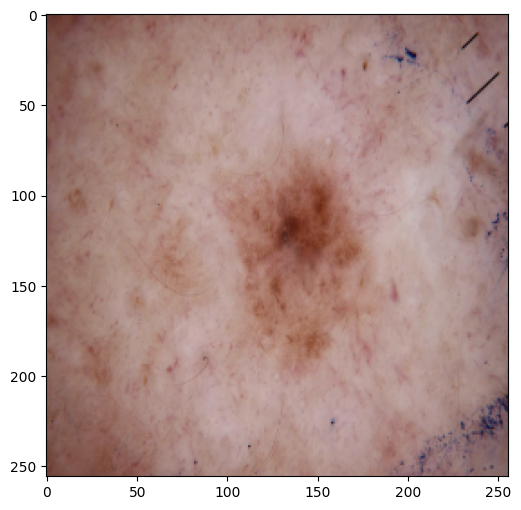

Primeras 5 imágenes en la carpeta:
['ISIC_0027997.jpg', 'ISIC_0030963.jpg', 'ISIC_0024490.jpg', 'ISIC_0024980.jpg', 'ISIC_0026791.jpg']

Primera imagen en TRAIN_IMAGES:
ISIC_0026655


In [6]:
#prueba llamar a la dataset_generator
imagen_prueba = tf.constant(HAM10000_TRAIN_IMAGES[0])
ruta_imagen_prueba = HAM10000_IMAGES_PATH 
imagen, label = dataset_generator(imagen_prueba, ruta_imagen_prueba)

print("Imagen:", imagen)
print("Etiqueta:", label)

#imagen en foto:
plt.figure(figsize=(8, 6))
plt.imshow(imagen)
plt.show()

# Verificar qué imágenes existen
print("Primeras 5 imágenes en la carpeta:")
print(os.listdir(HAM10000_IMAGES_PATH)[:5])

print("\nPrimera imagen en TRAIN_IMAGES:")
print(HAM10000_TRAIN_IMAGES[0])

In [7]:
from functools import partial

def process_image(x):
    image, label = tf.py_function(
        partial(dataset_generator, files_path=HAM10000_IMAGES_PATH), 
        [x], 
        [tf.float32, tf.float32]
    )
    image.set_shape([None, None, 3])
    label.set_shape([7])
    return image, label

train_filenames = tf.constant(HAM10000_TRAIN_IMAGES)
train_dataset = tf.data.Dataset.from_tensor_slices((train_filenames))
train_dataset = train_dataset.map(process_image, num_parallel_calls=tf.data.experimental.AUTOTUNE, deterministic=False)
train_dataset = train_dataset.map(lambda x, y: (tf.image.resize(x, [224, 224]), y))
train_dataset = train_dataset.repeat()
train_dataset = train_dataset.batch(1).prefetch(tf.data.experimental.AUTOTUNE)

validation_filenames = tf.constant(HAM10000_VAL_IMAGES)
validation_dataset = tf.data.Dataset.from_tensor_slices((validation_filenames))
validation_dataset = validation_dataset.map(process_image, num_parallel_calls=tf.data.experimental.AUTOTUNE, deterministic=False)
validation_dataset = validation_dataset.map(lambda x, y: (tf.image.resize(x, [224, 224]), y))
validation_dataset = validation_dataset.repeat()
validation_dataset = validation_dataset.batch(1).prefetch(tf.data.experimental.AUTOTUNE)

test_filenames = tf.constant(HAM10000_TEST_IMAGES)
test_dataset = tf.data.Dataset.from_tensor_slices((test_filenames))
test_dataset = test_dataset.map(process_image, num_parallel_calls=tf.data.experimental.AUTOTUNE, deterministic=False)
test_dataset = test_dataset.map(lambda x, y: (tf.image.resize(x, [224, 224]), y))
test_dataset = test_dataset.repeat()
test_dataset = test_dataset.batch(1).prefetch(tf.data.experimental.AUTOTUNE)

In [8]:
#comprovar, amb algunes iteracions inicials , que ens torna tota la informació que necessitam per a la passa de classificació directa: imatge, i classe de la imatge codificada amb one-hot.
#iterator_train = iter(train_dataset) #iterador para ir recorriendo batch por batch

#for step in range(0, 10):
    #batch_img, batch_labels_dict = iterator_train.next()  # ⬅️ batch_labels_dict es un DICCIONARIO completo
    
    # ⬅️ CORRECCIÓN: Iterar sobre las imágenes y acceder al diccionario directamente
    #for i, img in enumerate(batch_img):
        # Acceder a las labels desde el diccionario (no iterar sobre él)
        #classification_label = batch_labels_dict['classification_output'][i]  # ⬅️ CORRECTO
        #reconstruction_target = batch_labels_dict['reconstruction_output'][i]  # ⬅️ Opcional para ver
        
        #muestra visual
        #fig, axs = plt.subplots(1, 2, figsize=(13,13))
        #axs[0].imshow(img)
        #axs[0].set_title('Dermatological image')
        #axs[1].bar(range(len(classification_label)), classification_label)
        #axs[1].set_title('One-Hot label')
        #axs[1].set_xlabel('Classes')
        #axs[1].set_ylabel('Value')
        
        #plt.show()
        
#iterator_train = iter(train_dataset)

#for step in range(0, 20):
    #batch_img, batch_labels_dict = iterator_train.next()
    
    # Verificar la estructura
    #print("Tipo de batch_labels_dict:", type(batch_labels_dict))
    #print("Claves del diccionario:", batch_labels_dict.keys())
    #print("Shape de batch_img:", batch_img.shape)
    #print("Shape de classification_output:", batch_labels_dict['classification_output'].shape)
    #print("Shape de reconstruction_output:", batch_labels_dict['reconstruction_output'].shape)
    #print("---")
    
    # ⬅️ CORRECCIÓN: Acceder a elementos individuales usando índices
    #for i in range(len(batch_img)):
        #img = batch_img[i]
        #classification_label = batch_labels_dict['classification_output'][i]
        #reconstruction_target = batch_labels_dict['reconstruction_output'][i]
        
        #verificar dimensiones
        #print("Image shape:", img.shape)
        #print("Reconstruction target shape:", reconstruction_target.shape)
        #print("Classification label shape:", classification_label.shape)
        #print("---")

#visualizar imagen    etiqueta      
# for train_image_name in HAM10000_TRAIN_IMAGES:
#     print(train_image_name)
#     train_image_path = os.path.join(HAM10000_IMAGES_PATHS[0], train_image_name + ".jpg")
#     image = cv2.imread(train_image_path)[:, :, ::-1]
#     image = cv2.resize(image, (256, 256))
#     image = normalize_image(image)
    
#     label = HAM10000_LABELS_DICT[train_image_name]

#     fig, axs = plt.subplots(1, 2, figsize=(10,5))
#     axs[0].imshow(image)
#     axs[0].set_title('Imagen Original')
#     axs[1].bar(range(len(label)), label)
#     axs[1].set_title('Etiqueta One-Hot')
    
#     plt.show()

## Entrenament del model

## Implementació de la UNet
U-Net Architecture
The architecture is symmetric and has three key parts:

1. Contracting Path (Encoder):

Uses small filters (3×3 pixels) to scan the image and find features.
Apply an activation function called ReLU to add non-linearity help the model to learn better.
Uses max pooling (2×2 filters) to shrink the image size while keeping important information. This helps the network focus on bigger features.

2. Bottleneck:

The middle of the “U” where the most compressed and abstract information is stored. It links the encoder and decoder.

3. Expansive Path (Decoder):

Uses upsampling i.e increasing image size to get back the original image size.
Combines information from the encoder using “skip connections.” These connections help the decoder get spatial details that might have been lost when shrinking the image.
Uses convolution layers again to clean up and refine the output.

## Key Components of CNNs

Convolutional Layers: These layers apply filters to the input image to create feature maps. The filters, or kernels, slide over the image, detecting features such as edges, textures, and patterns.

Activation Functions: Non-linear functions like Re LU (Rectified Linear Unit) are applied to the feature maps to introduce non-linearity, allowing the network to learn complex patterns.

Pooling Layers: These layers reduce the spatial dimensions of the feature maps, retaining important information while decreasing computational complexity. Common pooling techniques include max pooling and average pooling.

Fully Connected Layers: After several convolutional and pooling layers, the final feature maps are flattened and passed through fully connected layers to make predictions or classifications.

Output Layer: This layer generates the final predictions, often using soft max for classification tasks.

### 1. DEFINICIÓN DEL MODELO - VGG16

Model: "VGG16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 224, 224, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 224, 224, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 112, 112, 64)      0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 112, 112, 128)     73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 112, 112, 128)     147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 56, 56, 128)       0     

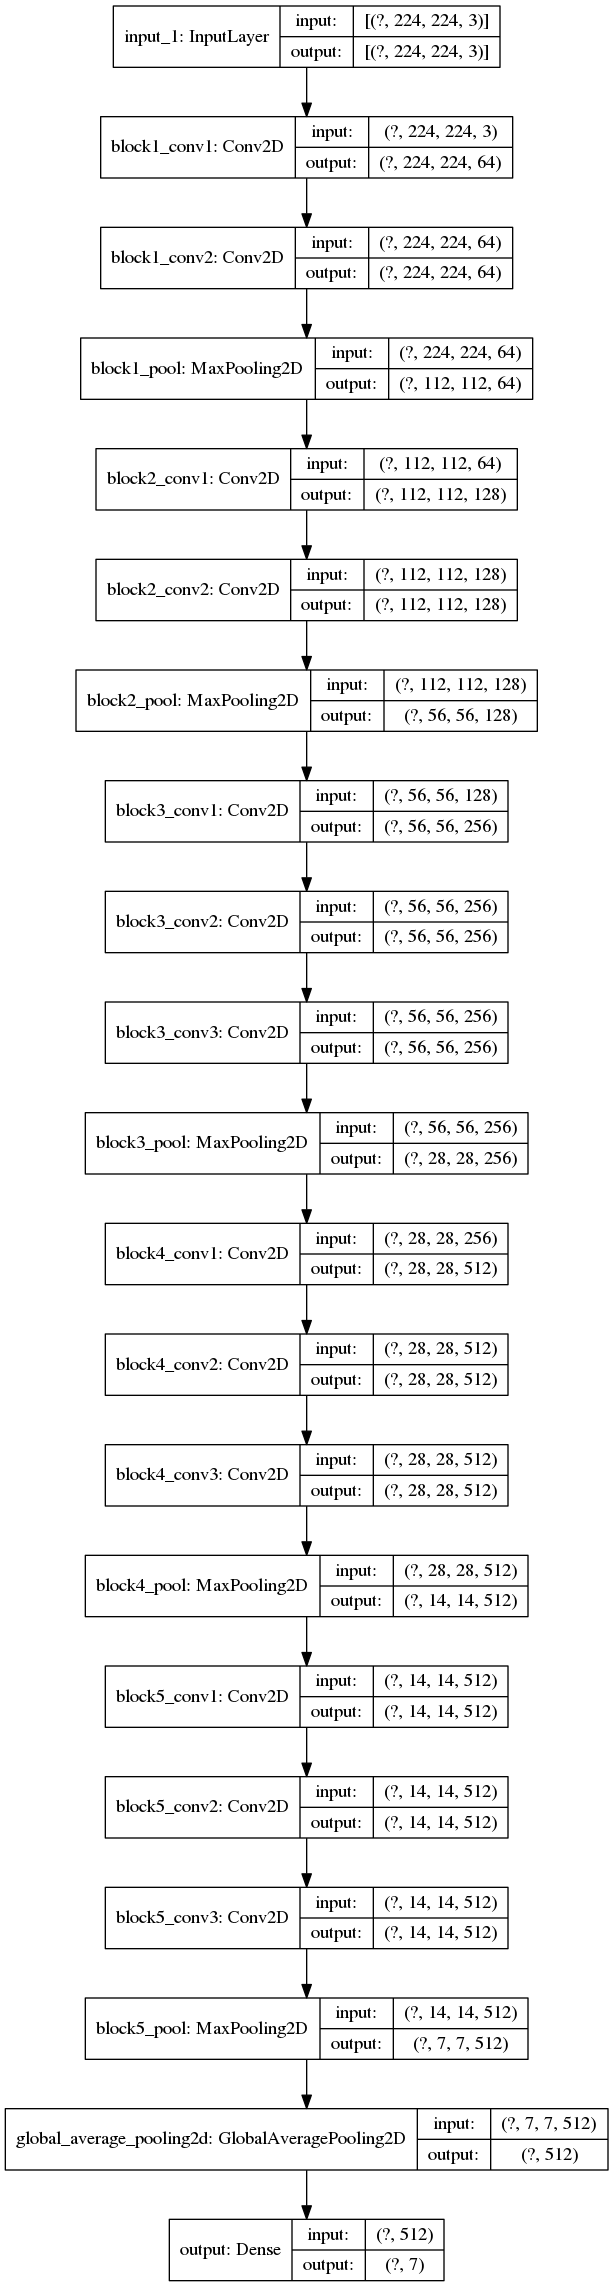

In [9]:

import os
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

model_i = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

x = model_i.output
x = GlobalAveragePooling2D()(x)

predictions = Dense(7, activation='softmax', name='output')(x)  # ← 7 clases

# Crear modelo
model = Model(inputs=model_i.input, outputs=predictions, name='VGG16')

# Verificar
model.summary()

tf.keras.utils.plot_model(model, to_file='vgg16-image-classifier.png', show_shapes=True, show_layer_names=True)

### 2.COMPILACIÓN


In [10]:

import tensorflow as tf

#Mean Squared Error (MSE) and Categorical Cross-Entropy (CCE)
#automática de Tensorflow, loss weights puedo considerar los que quiera, luego puedo ir haciendo el modelo con diferentes a ver que tal va.

model.compile(
    loss="categorical_crossentropy", 
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=["accuracy"]
)

#no es necessari
#manual 
#def dermatology_loss(y_true, y_pred):
#    reconstruction_loss = tf.reduce_mean(
#        tf.square(y_true['reconstruction_output'] - y_pred['reconstruction_output'])
#    )
    
#    classification_loss = tf.keras.losses.categorical_crossentropy(
#        y_true['classification_output'], y_pred['classification_output']
#    )
    
#    total_loss = 0.3 * reconstruction_loss + 0.7 * classification_loss
    
#     return total_loss 

#model.compile(
#    optimizer='adam',
#    loss=dermatology_loss,  # o classification_only_loss
#    metrics=['accuracy', 'categorical_accuracy']
#)

## Qualitat de l'entrenament
No basta només amb entrenar la xarxa. També hem de poder avaluar la qualitat de l'entrenament. Per això, la variable training_history té aquesta informació.

#guardar modelos
#calculo de metricas y graficos de evolucion de las metricas. RMSE
#graficas del entrenamiento

### Entrenamiento del modelo, calidad del modelo

In [12]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
BATCH_SIZE = 1 #4
TOTAL_TRAIN_IMAGES = len(HAM10000_TRAIN_IMAGES)
STEPS_PER_EPOCH = TOTAL_TRAIN_IMAGES // BATCH_SIZE
EPOCHS = 50  

# CALLBACKS OPTIMIZADOS PARA HAM10000, ajusta la velocidad de aprendizaje de tu modelo durante el entrenamiento. lr = learning rate
reduceLROnPlat = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.000001, verbose=1)                  
                 
#stopping, dice: "¡Ya para! El modelo ya no está mejorando"
early = EarlyStopping(monitor="val_loss", mode="min", patience=10, restore_best_weights=True, verbose=1)
#val_loss perdida de validación
#Espera 10 épocas sin mejora antes de parar


#Equipo de gestión automática del entrenamiento, 1.reduceLROnPlateau: Ajusta velocidad de aprendizaje, 2. EarlyStopping: Decide cuándo terminar

#Juntos: Garantizan el mejor modelo posible
CALLBACKS = [reduceLROnPlat, early]

In [13]:
import time
start_time = time.time()

#Contiene TODO lo que pasó durante las épocas de entrenamiento. #añadir coste computacional
training_history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    callbacks=CALLBACKS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=validation_dataset,
    validation_steps=len(HAM10000_VAL_IMAGES) // BATCH_SIZE,
    verbose=2  #evitar error IOPub message rate exceeded.
)


end_time = time.time()
total_time = end_time - start_time

print(f"Tiempo total de entrenamiento: {total_time:.2f} segundos")
print(f"Tiempo por época: {total_time / EPOCHS:.2f} segundos")

Epoch 1/50


2025-10-31 08:06:30.470606: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2025-10-31 08:06:31.146893: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudnn.so.7


6009/6009 - 124s - loss: 1.1638 - accuracy: 0.6673 - val_loss: 1.1224 - val_accuracy: 0.6695
Epoch 2/50
6009/6009 - 125s - loss: 1.5747 - accuracy: 0.6677 - val_loss: 1.1307 - val_accuracy: 0.6695
Epoch 3/50
6009/6009 - 127s - loss: 1.2993 - accuracy: 0.6663 - val_loss: 1.0385 - val_accuracy: 0.6695
Epoch 4/50
6009/6009 - 127s - loss: 1.0603 - accuracy: 0.6652 - val_loss: 1.0219 - val_accuracy: 0.6695
Epoch 5/50
6009/6009 - 127s - loss: 1.0020 - accuracy: 0.6662 - val_loss: 0.9727 - val_accuracy: 0.6695
Epoch 7/50
6009/6009 - 127s - loss: 1.0786 - accuracy: 0.6673 - val_loss: 0.9757 - val_accuracy: 0.6695
Epoch 8/50
6009/6009 - 127s - loss: 0.9667 - accuracy: 0.6678 - val_loss: 0.9621 - val_accuracy: 0.6695
Epoch 9/50
6009/6009 - 127s - loss: 1.0950 - accuracy: 0.6653 - val_loss: 2.5983 - val_accuracy: 0.6695
Epoch 10/50
6009/6009 - 127s - loss: 1.0994 - accuracy: 0.6693 - val_loss: 0.9511 - val_accuracy: 0.6695
Epoch 11/50
6009/6009 - 127s - loss: 0.9931 - accuracy: 0.6672 - val_loss:

### Gráficos de evolución de las métricas

In [14]:
#gráficas de evolución
#visualització de la calidad del modelo
def plot_learning_curve(history, metrics):
    acc = history.history[metrics]
    val_acc = history.history[f'val_{metrics}']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(5,3))
    plt.plot(epochs, acc, label=f'training {metrics}')
    plt.plot(epochs, val_acc, label=f'validation {metrics}')
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(metrics)
    plt.legend()

    plt.figure(figsize=(5,3))
    plt.plot(epochs, loss, label='training loss')
    plt.plot(epochs, val_loss, label='validation loss')
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()


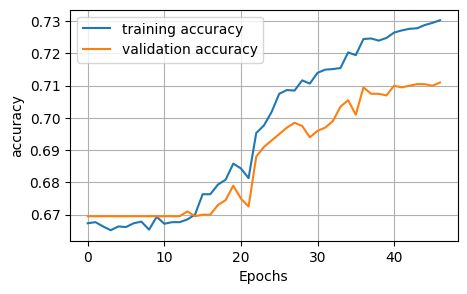

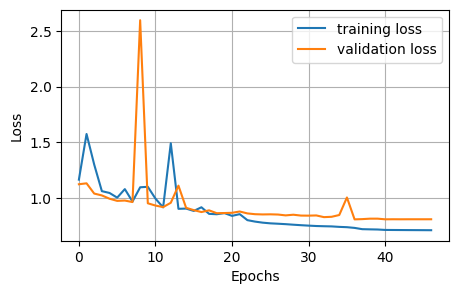

In [16]:
plot_learning_curve(training_history, metrics='accuracy')

### Guardar modelo
guardar el model en un fitxer, i recuperar-lo posteriorment per a fer les prediccions que puguin fer falta. L'extensió del fitxer sempre ha de ser .h5.

In [17]:
EXPERIMENT_PATH = "/home/marc/MARIADELMAR_EXPERIMENTS/experiment2_vgg16"
model.save(os.path.join(EXPERIMENT_PATH, "model_ham10000_multiclass.h5"))


OSError: Unable to create file (unable to open file: name = '/home/marc/MARIADELMAR_EXPERIMENTS/experiment2_vgg16/model_ham10000_multiclass.h5', errno = 2, error message = 'No such file or directory', flags = 13, o_flags = 242)

In [18]:
#recuperació del model:
from tensorflow.keras.models import load_model

loaded_model = load_model(
    os.path.join(EXPERIMENT_PATH, "vgg16_ham10000_multiclass.h5")
)

# Asignar el modelo cargado
model = loaded_model

OSError: SavedModel file does not exist at: /home/marc/MARIADELMAR_EXPERIMENTS/experiment2_vgg16/vgg16_ham10000_multiclass.h5/{saved_model.pbtxt|saved_model.pb}

### Calcular métricas globales

In [22]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import balanced_accuracy_score, cohen_kappa_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K

class_names = [
    'akiec',      # 0 - Actinic keratoses
    'bcc',        # 1 - Basal cell carcinoma  
    'bkl',        # 2 - Benign keratosis-like lesions
    'df',         # 3 - Dermatofibroma
    'mel',        # 4 - Melanoma
    'nv',         # 5 - Melanocytic nevi
    'vasc'        # 6 - Vascular lesions
]

test_predictions = model.predict(test_dataset, steps=len(HAM10000_TEST_IMAGES)) #predicciones de la unet
classification_pred = test_predictions  #classification_output from unet
#salida de reconstruccio guardar 50 y hacer visualizaciones ver en 6 casoso imagen noemal con reconstruccion
#obtener etiqueta real
y_true_classes = []
for images, labels in test_dataset.take(len(HAM10000_TEST_IMAGES)):
    true_class = np.argmax(labels.numpy(), axis=1)
    y_true_classes.extend(true_class)

y_true_classes = np.array(y_true_classes) #valor real
y_pred_classes = np.argmax(classification_pred, axis=1)
#CÁLCULO DE MÉTRICAS Genéricas
accuracy = accuracy_score(y_true_classes, y_pred_classes) #(Aciertos Totales) / (Total de Imágenes)
precision = precision_score(y_true_classes, y_pred_classes, average='weighted')#De las imágenes que predigo como melanoma, ¿cuántas realmente lo son?
recall = recall_score(y_true_classes, y_pred_classes, average='weighted') #De todos los melanomas reales que hay en las imágenes, ¿qué porcentaje logro detectar correctamente?
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted') #¿Cuál es el balance entre no asustar a pacientes sanos (precision) y no dejar escapar cánceres reales (recall)?
#añadar especificidad
#añadar especificidad
def specificity(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    true_negatives = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    possible_negatives = K.sum(K.round(K.clip(1 - y_true, 0, 1)))
    return true_negatives / (possible_negatives + K.epsilon())

specificity_metric = specificity(y_true_classes.astype('float32'),
                                 y_pred_classes.astype('float32'))



#métricas específicas
#The balanced accuracy in binary and multiclass classification problems to deal with imbalanced datasets. 
#This function computes Cohen’s kappa [1], a score that expresses the level of agreement between two annotators on a classification problem. 
balanced_acc = balanced_accuracy_score(y_true_classes, y_pred_classes)
kappa = cohen_kappa_score(y_true_classes, y_pred_classes)
#AUC: qué tan bien tu modelo puede distinguir entre imágenes de melanoma y no melanoma.
y_true_binary_mel = (y_true_classes == 4).astype(int)
y_pred_proba_mel = classification_pred[:, 4]  
auc_mel = roc_auc_score(y_true_binary_mel, y_pred_proba_mel)


print("Métricas globales")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Specificity: {K.get_value(specificity_metric):.4f}")

print(f"Balanced accuracy: {balanced_acc:.4f}")
print(f"Cohen's Kappa:     {kappa:.4f}")
print(f"AUC Melanoma:      {auc_mel:.4f}")

#Build a text report showing the main classification metrics.
print("Métricas por clase")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names, zero_division=0))
#Support es el número real de muestras/imágenes que hay de cada clase en tu dataset de test.

Métricas globales
Accuracy:  0.6086
Precision: 0.5483
Recall:    0.6086
F1-Score:  0.5696
Specificity: 25.9848
Balanced accuracy: 0.2122
Cohen's Kappa:     0.1384
AUC Melanoma:      0.6278
Métricas por clase
              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        66
         bcc       0.15      0.22      0.18       103
         bkl       0.22      0.14      0.17       219
          df       0.00      0.00      0.00        23
         mel       0.25      0.13      0.17       223
          nv       0.72      0.84      0.78      1341
        vasc       0.67      0.14      0.24        28

    accuracy                           0.61      2003
   macro avg       0.29      0.21      0.22      2003
weighted avg       0.55      0.61      0.57      2003



/home/marc/anaconda3/envs/experiments_mariadelmar/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Confusion Matrix:
 [[   0   13    8    0    3   42    0]
 [   0   23   14    0    6   60    0]
 [   1   28   31    0   16  143    0]
 [   0    2    0    0    1   19    1]
 [   0    7   17    0   30  169    0]
 [   1   75   69    0   64 1131    1]
 [   0    5    5    0    1   13    4]]
Perfect Confusion Matrix:
 [[  66    0    0    0    0    0    0]
 [   0  103    0    0    0    0    0]
 [   0    0  219    0    0    0    0]
 [   0    0    0   23    0    0    0]
 [   0    0    0    0  223    0    0]
 [   0    0    0    0    0 1341    0]
 [   0    0    0    0    0    0   28]]


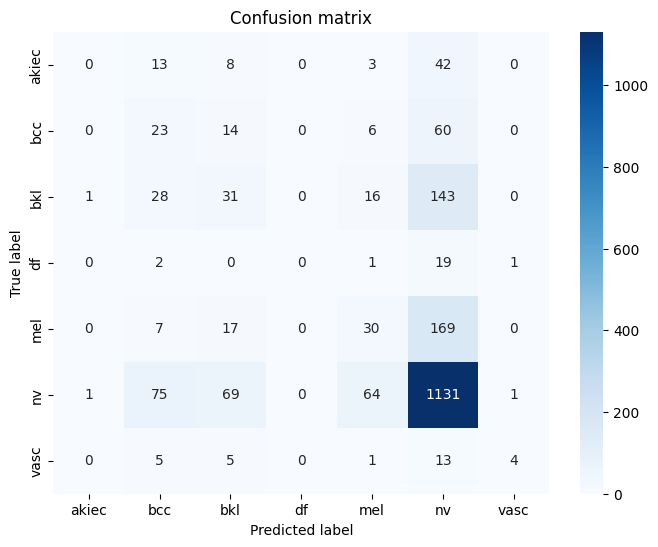

In [25]:
import sys
!{sys.executable} -m pip install seaborn
import seaborn as sns

#matriz de confusión
#una matriz de confusión clasifica las predicciones del modelo en 
#Verdaderos Positivos, Falsos Positivos, Verdaderos Negativos y Falsos Negativos. 

#Los elementos diagonales representan el número de puntos para los que la etiqueta predicha es igual a la verdadera, 
#mientras que los elementos fuera de la diagonal son los que el clasificador ha etiquetado erróneamente.
#Cuanto más altos sean los valores diagonales de la matriz de confusión, mejor, ya que indican muchas predicciones correctas.


# Calculate confusion matrix
confusion = confusion_matrix(y_true_classes, y_pred_classes)
print("Confusion Matrix:\n", confusion)
#calculate perfect confucion matrix
p_confusion = confusion_matrix(y_true_classes, y_true_classes)
print("Perfect Confusion Matrix:\n", p_confusion)

# Cada celda (i, j), número de imágenes de clase i que fueron clasificadas como j.
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [26]:
# Extrae los índices donde la predicción fue incorrecta
wrong_pred = np.where(y_pred_classes != y_true_classes)[0]
print(f'Total of {len(wrong_pred)} missclassified images')
print('Missclassified images index: ',wrong_pred)

test_iterator = iter(test_dataset)

images, true_labels = next(test_iterator)

class_names = [
    'akiec',      # 0 - Actinic keratoses
    'bcc',        # 1 - Basal cell carcinoma  
    'bkl',        # 2 - Benign keratosis-like lesions
    'df',         # 3 - Dermatofibroma
    'mel',        # 4 - Melanoma
    'nv',         # 5 - Melanocytic nevi
    'vasc'        # 6 - Vascular lesions
]

class_map = {0: 'akiec', 1: 'bcc', 2: 'bkl', 3:'df', 4:'mel', 5:'nv', 6:'vasc'}

Total of 784 missclassified images
Missclassified images index:  [   5    6   10   11   12   13   15   17   20   21   24   28   30   31
   33   36   40   41   42   44   45   46   47   49   50   51   52   53
   55   56   57   59   60   61   64   72   75   77   80   83   85   86
   93   95   97   98  101  102  103  104  118  121  124  126  135  136
  138  139  140  142  143  147  148  154  155  156  157  161  166  167
  168  172  173  174  176  179  180  181  182  184  185  186  187  188
  199  205  208  213  214  215  217  222  223  224  226  230  231  234
  235  236  238  241  245  251  252  254  256  259  260  265  267  270
  271  272  273  277  279  282  283  286  287  290  298  299  301  305
  307  308  316  321  322  323  325  329  330  335  338  344  347  348
  349  352  359  362  368  369  370  373  375  376  382  383  384  393
  396  397  399  403  408  421  422  423  424  425  426  427  433  436
  439  441  442  443  444  447  448  450  456  457  458  459  463  465
  467  469  

In [1]:
plt.figure(figsize=(15, 3))

# Convertir el dataset de test a una lista para poder acceder por índice
test_data_list = list(test_dataset.as_numpy_iterator())

for i, wrong_index in enumerate(wrong_pred[:5]):
    plt.subplot(1, 5, i + 1)
    
    # Obtener el batch específico donde está la predicción incorrecta
    images, true_labels = test_data_list[wrong_index]
    
    # Mostrar la imagen (primer elemento del batch)
    plt.imshow((images[0] * 255).astype('uint8'))  # [0] porque batch_size=1
    
    # Obtener clases verdadera y predicha
    true_class = np.argmax(true_labels['classification_output'][0])
    pred_class = y_pred_classes[wrong_index]
    
    plt.text(5, 10, f"True: {class_map[true_class]}",
             color='green', bbox=dict(facecolor='white', alpha=0.6))
    plt.text(5, 30, f"Pred: {class_map[pred_class]}",
             color='red', bbox=dict(facecolor='white', alpha=0.6))
    
    plt.axis('off')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined